In [1]:
import numpy as np
np.random.seed(42)

N = 2000
X = np.random.uniform(-3, 3, (N, 3))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]

# Nonlinear deterministic function
Y = np.sin(x1) + x2**2 + np.log(1 + np.abs(x3)) + 0.5 * x1 * x3
Y = Y.reshape(-1, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: (2000, 3)
Y shape: (2000, 1)


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

X_pt = torch.tensor(X, dtype=torch.float32)
Y_pt = torch.tensor(Y, dtype=torch.float32)

class PyTorchDNN(nn.Module):
    def __init__(self):
        super(PyTorchDNN, self).__init__()
        self.layer1 = nn.Linear(3, 64)
        self.layer2 = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        return self.output(x)

model = PyTorchDNN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 1000
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    preds = model(X_pt)
    loss = criterion(preds, Y_pt)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item():.4f}")

predictions = model(X_pt).detach().numpy()

Epoch 100/1000 - Loss: 0.3262
Epoch 200/1000 - Loss: 0.1927
Epoch 300/1000 - Loss: 0.1202
Epoch 400/1000 - Loss: 0.0891
Epoch 500/1000 - Loss: 0.0709
Epoch 600/1000 - Loss: 0.0579
Epoch 700/1000 - Loss: 0.0481
Epoch 800/1000 - Loss: 0.0405
Epoch 900/1000 - Loss: 0.0344
Epoch 1000/1000 - Loss: 0.0295


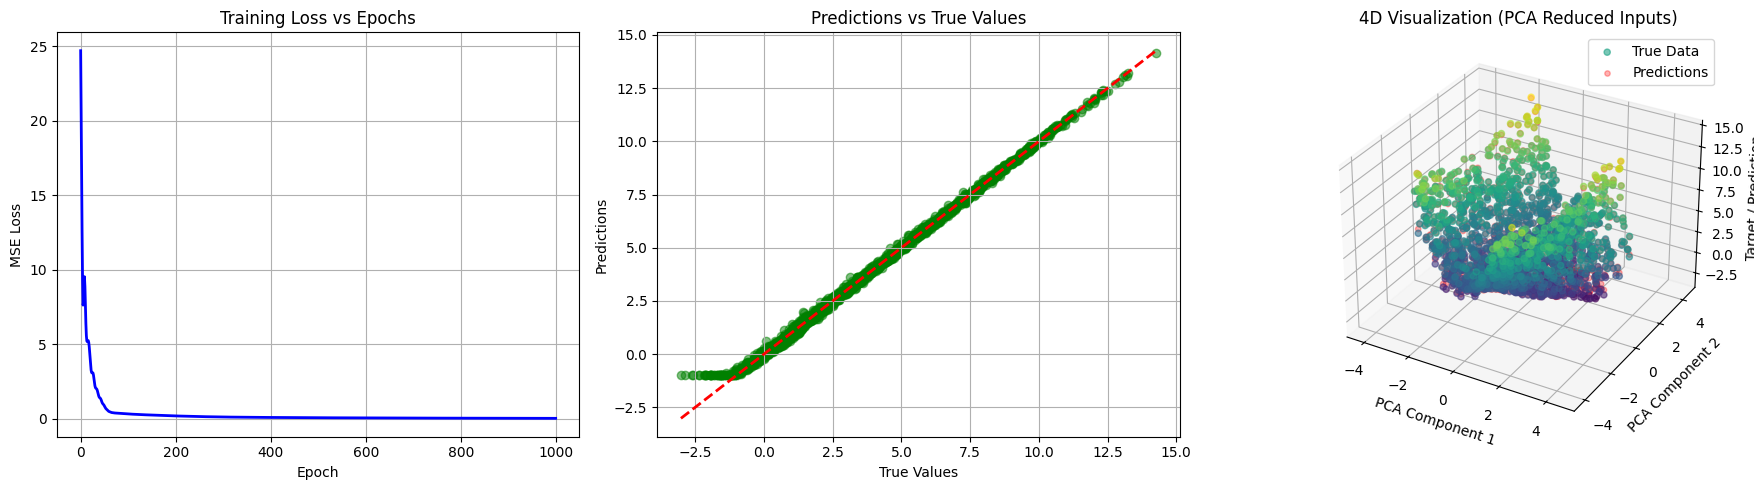

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

fig = plt.figure(figsize=(18, 5))

# Plot 1: Loss vs Epochs
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(losses, color='blue', linewidth=2)
ax1.set_title("Training Loss vs Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.grid(True)

# Plot 2: Predictions vs True Values
ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(Y, predictions, alpha=0.5, color='green')
ax2.plot([Y.min(), Y.max()], [Y.min(), Y.max()], 'r--', lw=2)
ax2.set_title("Predictions vs True Values")
ax2.set_xlabel("True Values")
ax2.set_ylabel("Predictions")
ax2.grid(True)

# Plot 3: 4D Visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

ax3 = fig.add_subplot(1, 3, 3, projection='3d')
sc = ax3.scatter(X_pca[:, 0], X_pca[:, 1], Y.flatten(), c=Y.flatten(), cmap='viridis', alpha=0.6, label='True Data')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], predictions.flatten(), color='red', alpha=0.3, s=15, label='Predictions')
ax3.set_title("4D Visualization (PCA Reduced Inputs)")
ax3.set_xlabel("PCA Component 1")
ax3.set_ylabel("PCA Component 2")
ax3.set_zlabel("Target / Prediction")
ax3.legend()

plt.tight_layout()
plt.show()
